# Optic flow task


This notebook illustrates the optic flow task and how to use it with our pretrained fly visual system model and decoder.

**Select GPU runtime**

To run the notebook on a GPU select Menu -> Runtime -> Change runtime type -> GPU.

In [1]:
# @markdown **Check access to GPU**

try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if True:
    import torch

    try:
        cuda_name = torch.cuda.get_device_name()
        print(f"Name of the assigned GPU / CUDA device: {cuda_name}")
    except RuntimeError:
        import warnings

        warnings.warn(
            "You have not selected Runtime Type: 'GPU' or Google could not assign you one. Please revisit the settings as described above or proceed on CPU (slow)."
        )

Name of the assigned GPU / CUDA device: NVIDIA GeForce RTX 2080


**Install Flyvis**

The notebook requires installing our package `flyvis`. You may need to restart your session after running the code block below with Menu -> Runtime -> Restart session. Then, imports from `flyvis` should succeed without issue.

In [2]:
# @markdown **Install Flyvis**
if IN_COLAB:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]

# The Sintel dataset

We use the Sintel dataset to train our models as described in the paper. More infos about the Sintel dataset can be found on the official Sintel website: http://sintel.is.tue.mpg.de/.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.analysis.animations.sintel import SintelSample
from flyvis.datasets.FT3D import MultiTaskFlyingThings3D


The class `MultiTaskSintel` loads, preprocesses, renders, and augments the sintel data. It adheres to the pytorch dataset primitive. It provides the interface to the input data and the output data for the flyvis networks. Note: the fly-eye rendering we use here, we introduce in the notebook on creating custom stimuli already.

This is the full setting:

In [4]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    # Because the fly eye rendering is square
    # and sintel is wide, we can crop sintel
    # in width and render three sequences from one.
    # This allows us to statically augment our dataset
    # a bit already before we proceed with the random augmentations.
    # We end up with 3 * 23 sequences.
    vertical_splits=3,
    n_frames=19,
    center_crop_fraction=0.7,
    dt=1 / 50,
    augment=True,
    # From sequences with more than n_frames, we randomly sample the start frame.
    random_temporal_crop=True,
    all_frames=False,
    # We resample movie frames to the effective framerate given by 1/dt
    resampling=True,
    # We interpolate the flow arrows to 1/dt.
    interpolate=True,
    # We flip with equal probability (using one flip-axis).
    p_flip=0.5,
    flip_axes=[0, 1],
    # We rotate with equal probability (using five fold rotation symmetry of the hex-grid).
    p_rot=5 / 6,
    # We randomly adjust contrast and brightness.
    contrast_std=0.2,
    brightness_std=0.1,
    # We add random white noise pixelweise.
    gaussian_white_noise=0.08,
    gamma_std=None,
    _init_cache=True,
    unittest=False,
)
import os
from pathlib import Path
FT3D_ROOT      = Path(os.getenv("FT3D_ROOT", "/mnt/s/datasets/FlyingThings3D"))
augment = True
dataset1 = MultiTaskFlyingThings3D(
        ft3d_path=FT3D_ROOT,
        tasks=["rgb", "flow"],
        augment=augment,
        _init_cache=True,
    )

[2025-05-30 21:59:48] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [5]:
# The `dataset.arg_df` tracks the sequence index, identity etc.
#dataset.arg_df
dataset1.arg_df

,index,original_index,name,original_n_frames
0,0,0,sequence_00000_A_0000_split_00,9
1,1,0,sequence_00000_A_0000_split_01,9
2,2,0,sequence_00000_A_0000_split_02,9
3,3,1,sequence_00001_A_0001_split_00,9
4,4,1,sequence_00001_A_0001_split_01,9
...,...,...,...,...
4255,4255,2237,sequence_02237_C_0748_split_01,9
4256,4256,2237,sequence_02237_C_0748_split_02,9
4257,4257,2238,sequence_02238_C_0749_split_00,9
4258,4258,2238,sequence_02238_C_0749_split_01,9


## Single sample

First, let's chunk this into smaller digestable pieces.

In [6]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    dt=1 / 24,
    augment=False,
)

[2025-05-30 22:00:49] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


The first sample. For the target, the pixel-accurate motion vectors, the color indicates the direction of motion of the respective input pixel. The saturation indicates the magnitude of motion.

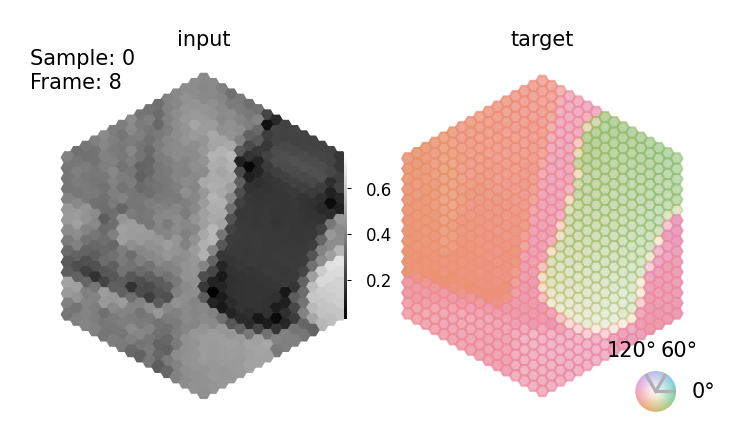

In [7]:
#lum = dataset[0]["lum"]
#flow = dataset[0]["flow"]

#animation = SintelSample(lum[None], flow[None])
#animation.animate_in_notebook()

lum = dataset1[2]["rgb"]
flow = dataset1[2]["flow"]

animation = SintelSample(lum[None], flow[None])
animation.animate_in_notebook()


Sintel has more groundtruth annotations. We support depth and flow because we know with some confidence that these are relevant for the fly.

In [8]:
dataset = MultiTaskSintel(
    tasks=["depth"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    dt=1 / 24,
    augment=False,
)

[2025-05-30 22:00:54] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet
[2025-05-30 22:00:54] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


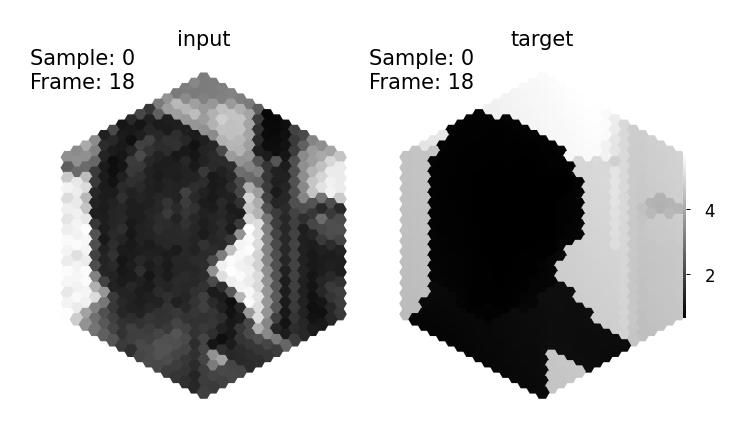

In [9]:
lum1 = dataset[0]["lum"]
depth1 = dataset[0]["depth"]

animation = SintelSample(lum1[None], depth1[None])
animation.animate_in_notebook()

# Augmenting the dataset step-by-step

We apply rich augmentations to the dataset of naturalistic sequences because the dataset is otherwise relatively small. This might lead to overfitting to, e.g., predicting motion mostly into well-represented directons or of objects of specific contrasts etc. Using rich augmentations, we 'ask' the network to generalize better and invariantly compute motion regardless of direction, contrast, brightness, pixel noise, temporal appearance etc.

## Vertical splits

First, we split each sequence into three sequences vertically to leverage a wider extent of the video than if we would only render the center. We precompute these renderings.

In [10]:
from flyvis.analysis.visualization.plots import quick_hex_scatter

In [11]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    dt=1 / 24,
    augment=False,
)

[2025-05-30 22:01:03] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


Sintel has 23 movie sequences originally.

In [12]:
len(np.unique(dataset.arg_df.original_index))

23

Each original sequence is 436 pixel in height times 1024 pixel in width in cartesian coordinates.

In [13]:
sequence = dataset.cartesian_sequence(0, vertical_splits=1, center_crop_fraction=1.0)
print(sequence.shape)

(1, 49, 436, 1024)


With the vertical crops, we end up with 3 * 23 sequences. The `dataset.arg_df` tracks the sequence index, identity etc.

In [14]:
dataset.arg_df

,index,original_index,name,original_n_frames
0,0,0,sequence_00_alley_1_split_00,50
1,1,0,sequence_00_alley_1_split_01,50
2,2,0,sequence_00_alley_1_split_02,50
3,3,1,sequence_01_alley_2_split_00,50
4,4,1,sequence_01_alley_2_split_01,50
...,...,...,...,...
64,64,21,sequence_21_temple_2_split_01,50
65,65,21,sequence_21_temple_2_split_02,50
66,66,22,sequence_22_temple_3_split_00,50
67,67,22,sequence_22_temple_3_split_01,50


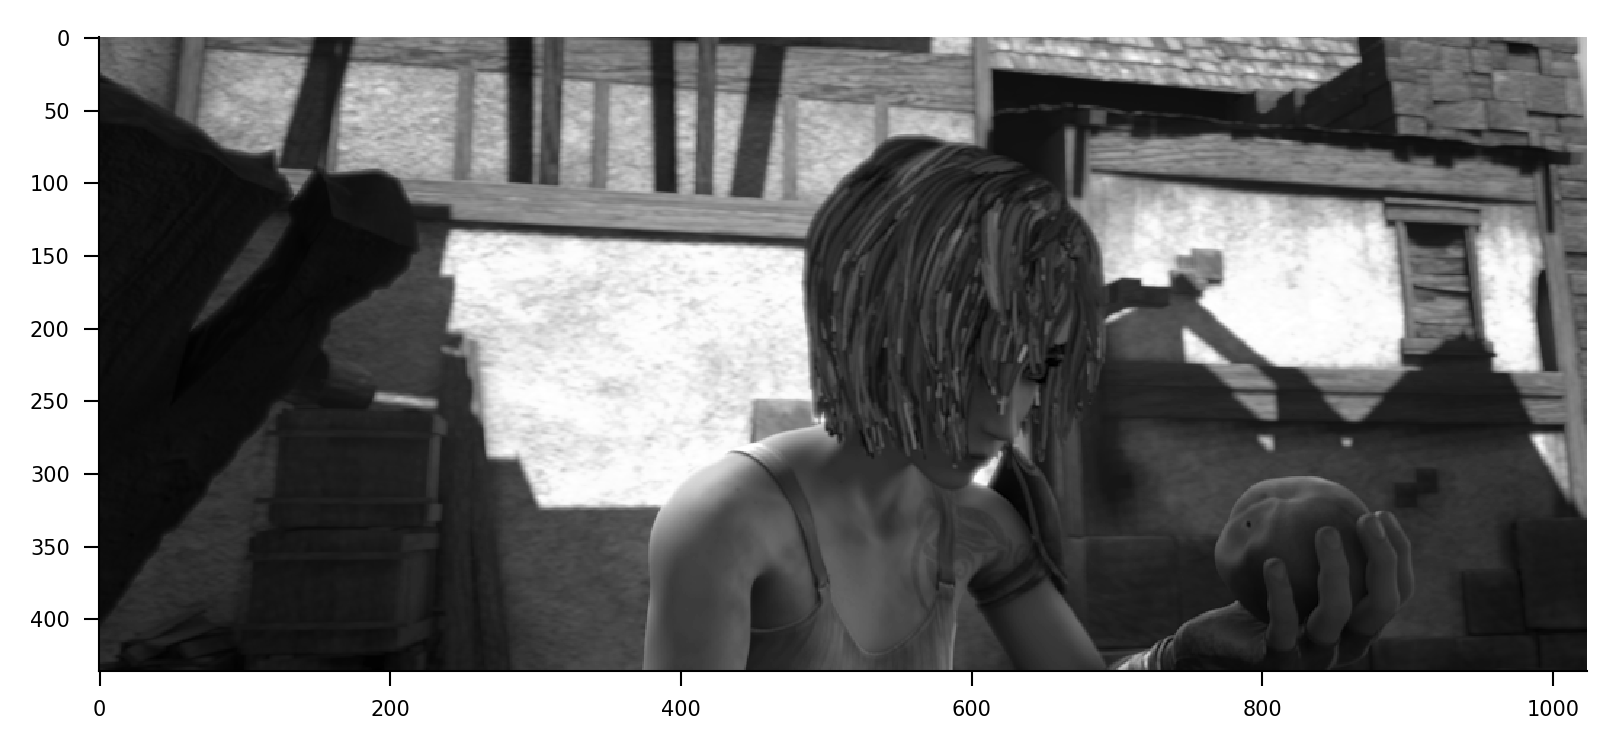

In [15]:
_ = plt.imshow(sequence[0, 0], cmap=plt.cm.binary_r)

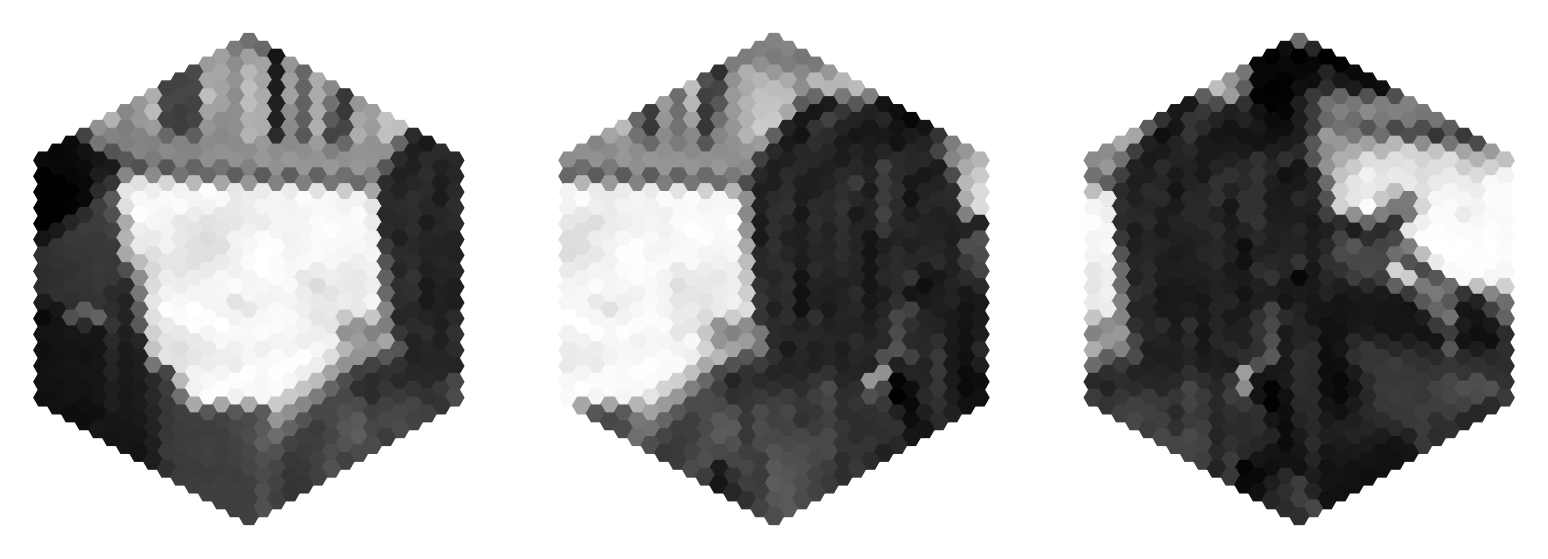

In [16]:
fig, axes = plt.subplots(1, 3)
_ = quick_hex_scatter(dataset[0]['lum'][0].flatten(), fig=fig, ax=axes[0], cbar=False)
_ = quick_hex_scatter(dataset[1]['lum'][0].flatten(), fig=fig, ax=axes[1], cbar=False)
_ = quick_hex_scatter(dataset[2]['lum'][0].flatten(), fig=fig, ax=axes[2], cbar=False)

## Random temporal crops

We train on 19 frames ~ 792ms movie. Most sequences have 49 frames. To use the whole temporal content, we stochastically sample start and end frame ~ ((1, 19), (2, 20), ..., (31, 49)).

In [17]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=True,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=0,
    p_rot=0,
    contrast_std=None,
    brightness_std=None,
    gaussian_white_noise=None,
)

[2025-05-30 22:01:05] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [18]:
# These two samples from the same original sequence should have stochastically different start and end frames.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

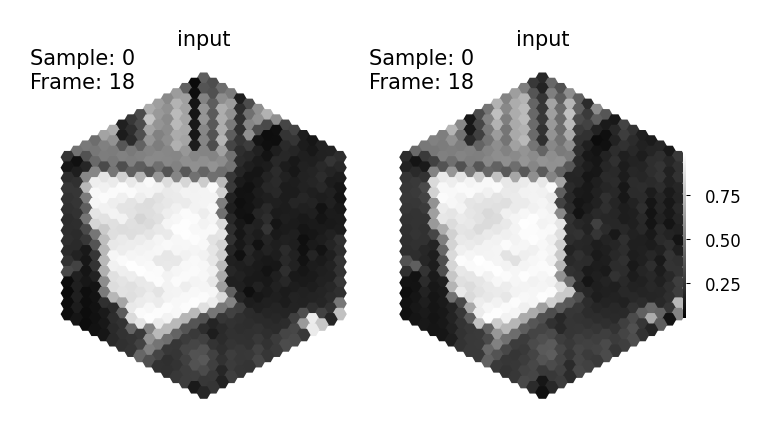

In [19]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

## Flips and rotations

Next, we flip stochastically across 2 axes and or rotate a random number of times around the center. We implement this to be fast to do so at runtime.

In [20]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=False,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=1 / 2,
    p_rot=5 / 6,
    contrast_std=None,
    brightness_std=None,
    gaussian_white_noise=None,
)

[2025-05-30 22:01:14] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [21]:
# These two samples from the same original sequence should have stochastically different orientation.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

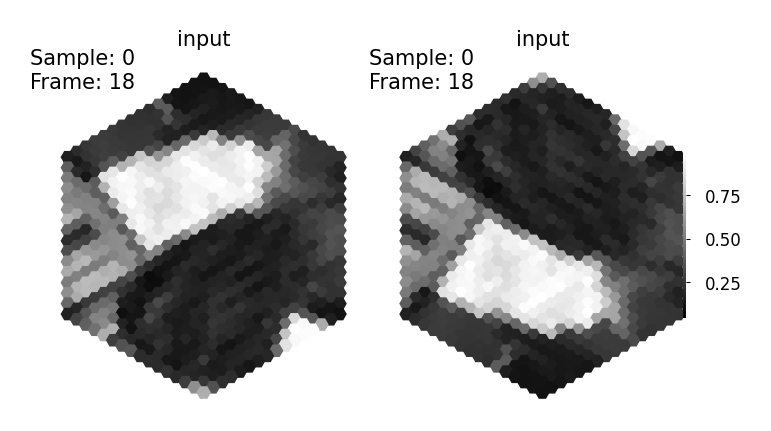

In [22]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

Flow vectors need to be flipped and rotated accordingly.

In [23]:
# These two samples from the same original sequence should have stochastically different orientation.
data = dataset[0]
lum1 = data['lum']
flow1 = data['flow']

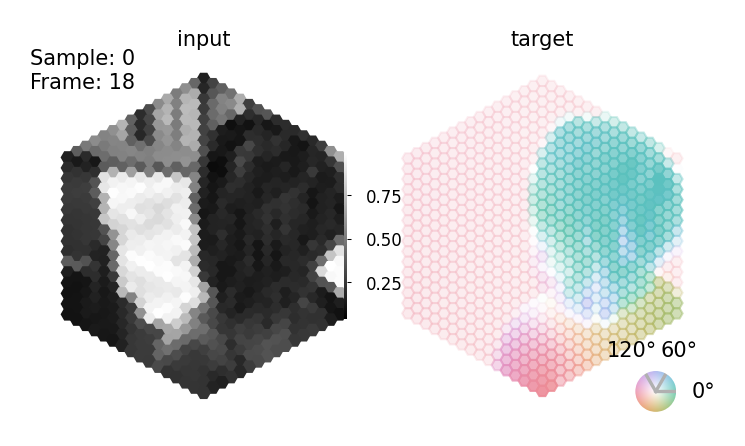

In [24]:
animation = SintelSample(lum1[None], flow1[None])
animation.animate_in_notebook()

## Further augmentations

Besides that, we also augment the input with random contrasts and brightnesses and random gaussian pixel noise, while the motion stays the same. This pretends that the same motion takes place under different illumination conditions and signal to noise ratios.  

In [25]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=False,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=0,
    p_rot=0,
    contrast_std=0.2,
    brightness_std=0.1,
    gaussian_white_noise=0.08,
)

[2025-05-30 22:01:33] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [26]:
# These two samples from the same original sequence have
# stochastically different contrast, brightness and pixel-wise noise.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

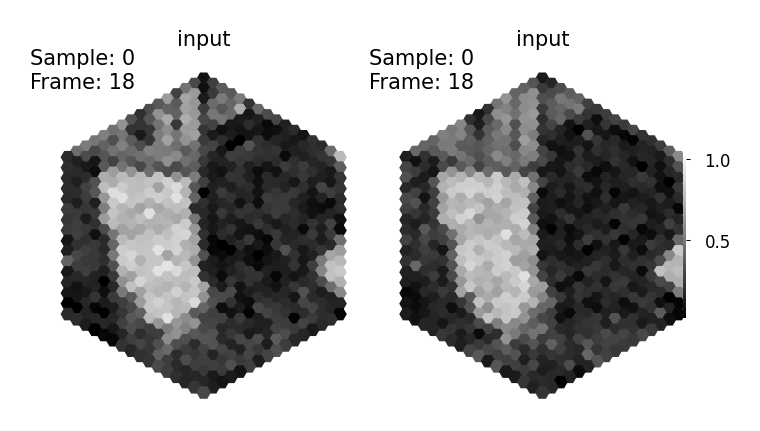

In [27]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

# Framerate of the dataset and integration time step

The Sintel dataset is originally rendered at 24 frames per second, i.e., one frame every 42ms. The fruit fly neurons are able to respond to temporal differences as fast as 5-20ms. Therefore, we resample every frame multiple times to pretend that the movie was originally sampled at such a faster framerate. For the motion fields, we interpolate flow vectors in time instead of resampling them, which hopefully gives a better learning signal to the network. We have to trade-off speed of the numerical integration and memory consumption during optimization with the simulation accuracy by choosing time steps between 5-20ms. We chose to train networks at the upper bount of 20ms and evaluate them more accurately at 5-10ms.

In [28]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

[2025-05-30 22:01:42] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [29]:
# Now, every input frame appears twice and target frames are interpolated.
data = dataset[0]
lum1 = data['lum']
flow1 = data['flow']

In [42]:
animation = SintelSample(lum1[None], flow1[None])
animation.animate_in_notebook()

NameError: name 'lum1' is not defined

# Computing responses to the Sintel data

Before we get to training a network, we look at a few responses to these type of sequences of individual neurons.

In [31]:
from flyvis.network import NetworkView, Network
from flyvis.utils.activity_utils import LayerActivity

from flyvis.datasets.sintel import MultiTaskSintel

In [32]:
# new network instance
network = Network()

# Alternative: uncomment to use a pretrained network
# network_view = NetworkView(results_dir / "flow/0000/000")
# network = network_view.init_network(network)

[2025-05-30 22:02:05] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


In [33]:
layer_activity = LayerActivity(None, network.connectome, keepref=True)

In [34]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)
dataset = dataset1

[2025-05-30 22:02:07] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [35]:
stationary_state = network.fade_in_state(1.0, dataset.dt, dataset[0]["rgb"][[0]])
responses = network.simulate(
    dataset[0]["rgb"][None], dataset.dt, initial_state=stationary_state
).cpu()

Text(0.5, 1.0, 'response of central T4c cell')

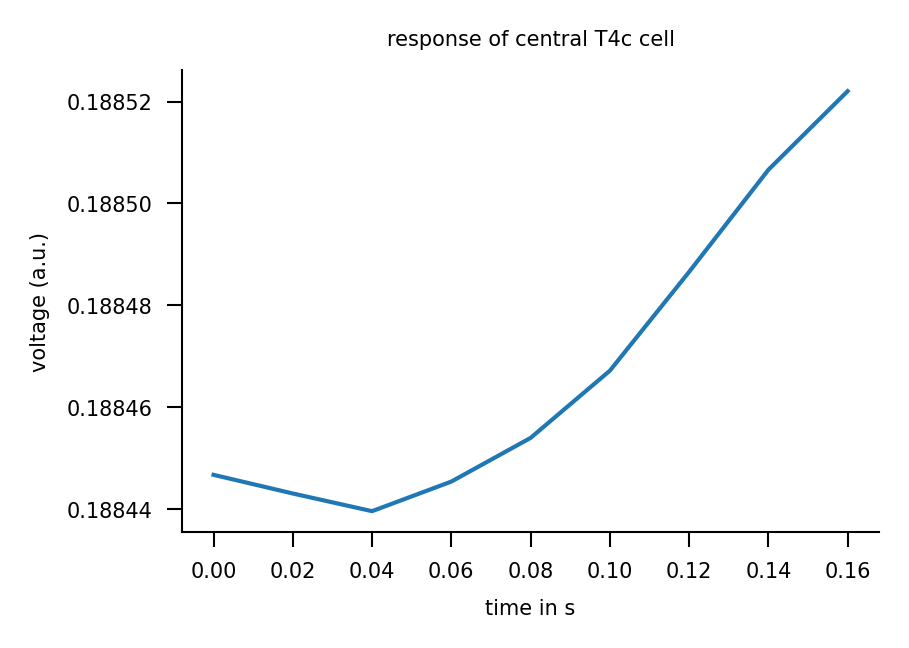

In [36]:
plt.figure(figsize=[3, 2])
layer_activity.update(responses)
r = layer_activity.central.T4c.squeeze().numpy()
time = np.arange(0, r.shape[0], 1) * dataset.dt
plt.plot(time, r)
plt.xlabel("time in s")
plt.ylabel("voltage (a.u.)")
plt.title("response of central T4c cell")

# Decoding the task from neural activity

We need to predict the pixel-accurate flow field that Sintel gives us. For that we decode the voltages of a bunch of cell types. The decoder and the network are trained end-to-end. Here an example of a forward pass through the whole pipeline in code.

In [37]:
from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.task.decoder import DecoderGAVP

In [38]:
network = Network()

[2025-05-30 22:02:09] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


In [39]:
decoder = DecoderGAVP(network.connectome, shape=[8, 2], kernel_size=5)

[2025-05-30 22:02:11] decoder:282 Initialized decoder with NumberOfParams(free=7427, fixed=0) parameters.
[2025-05-30 22:02:11] decoder:283 DecoderGAVP(
  (base): Sequential(
    (0): Conv2dHexSpace(34, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Softplus(beta=1.0, threshold=20.0)
    (3): Dropout(p=0.5, inplace=False)
  )
  (decoder): Sequential(
    (0): Conv2dHexSpace(8, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (head): Sequential()
)


In [40]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    all_frames=True,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

[2025-05-30 22:02:11] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [41]:
data = dataset[0]
lum = data["lum"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)

In [42]:
y_pred = decoder(responses)

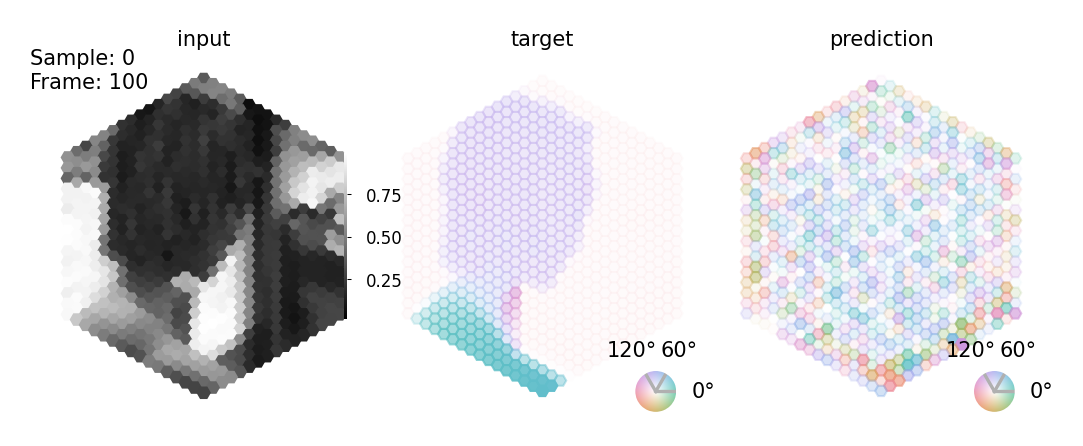

In [43]:
data = dataset[0]
lum = data["lum"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)
animation = SintelSample(lum[None], flow[None], prediction=y_pred.detach().cpu())
animation.animate_in_notebook(frames=np.arange(lum.shape[0])[::10])

We predict motion with an untrained decoder from an untrained network with randomly initialized parameters. 
We do not expect this to work.

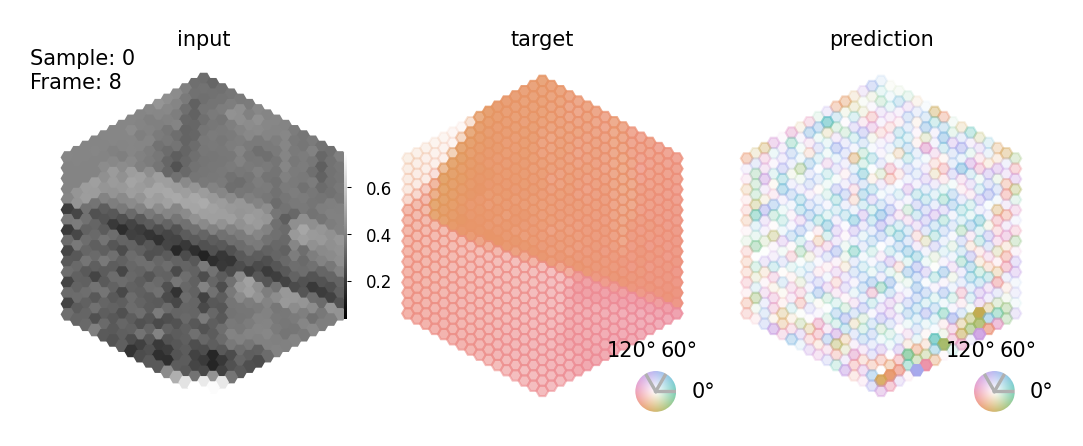

In [44]:
data = dataset1[0]
lum = data["rgb"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)
animation = SintelSample(lum[None], flow[None], prediction=y_pred.detach().cpu())
#animation.animate_in_notebook(frames=np.arange(lum.shape[0])[::10])
#animation = SintelSample(lum[None], flow[None])
animation.animate_in_notebook()

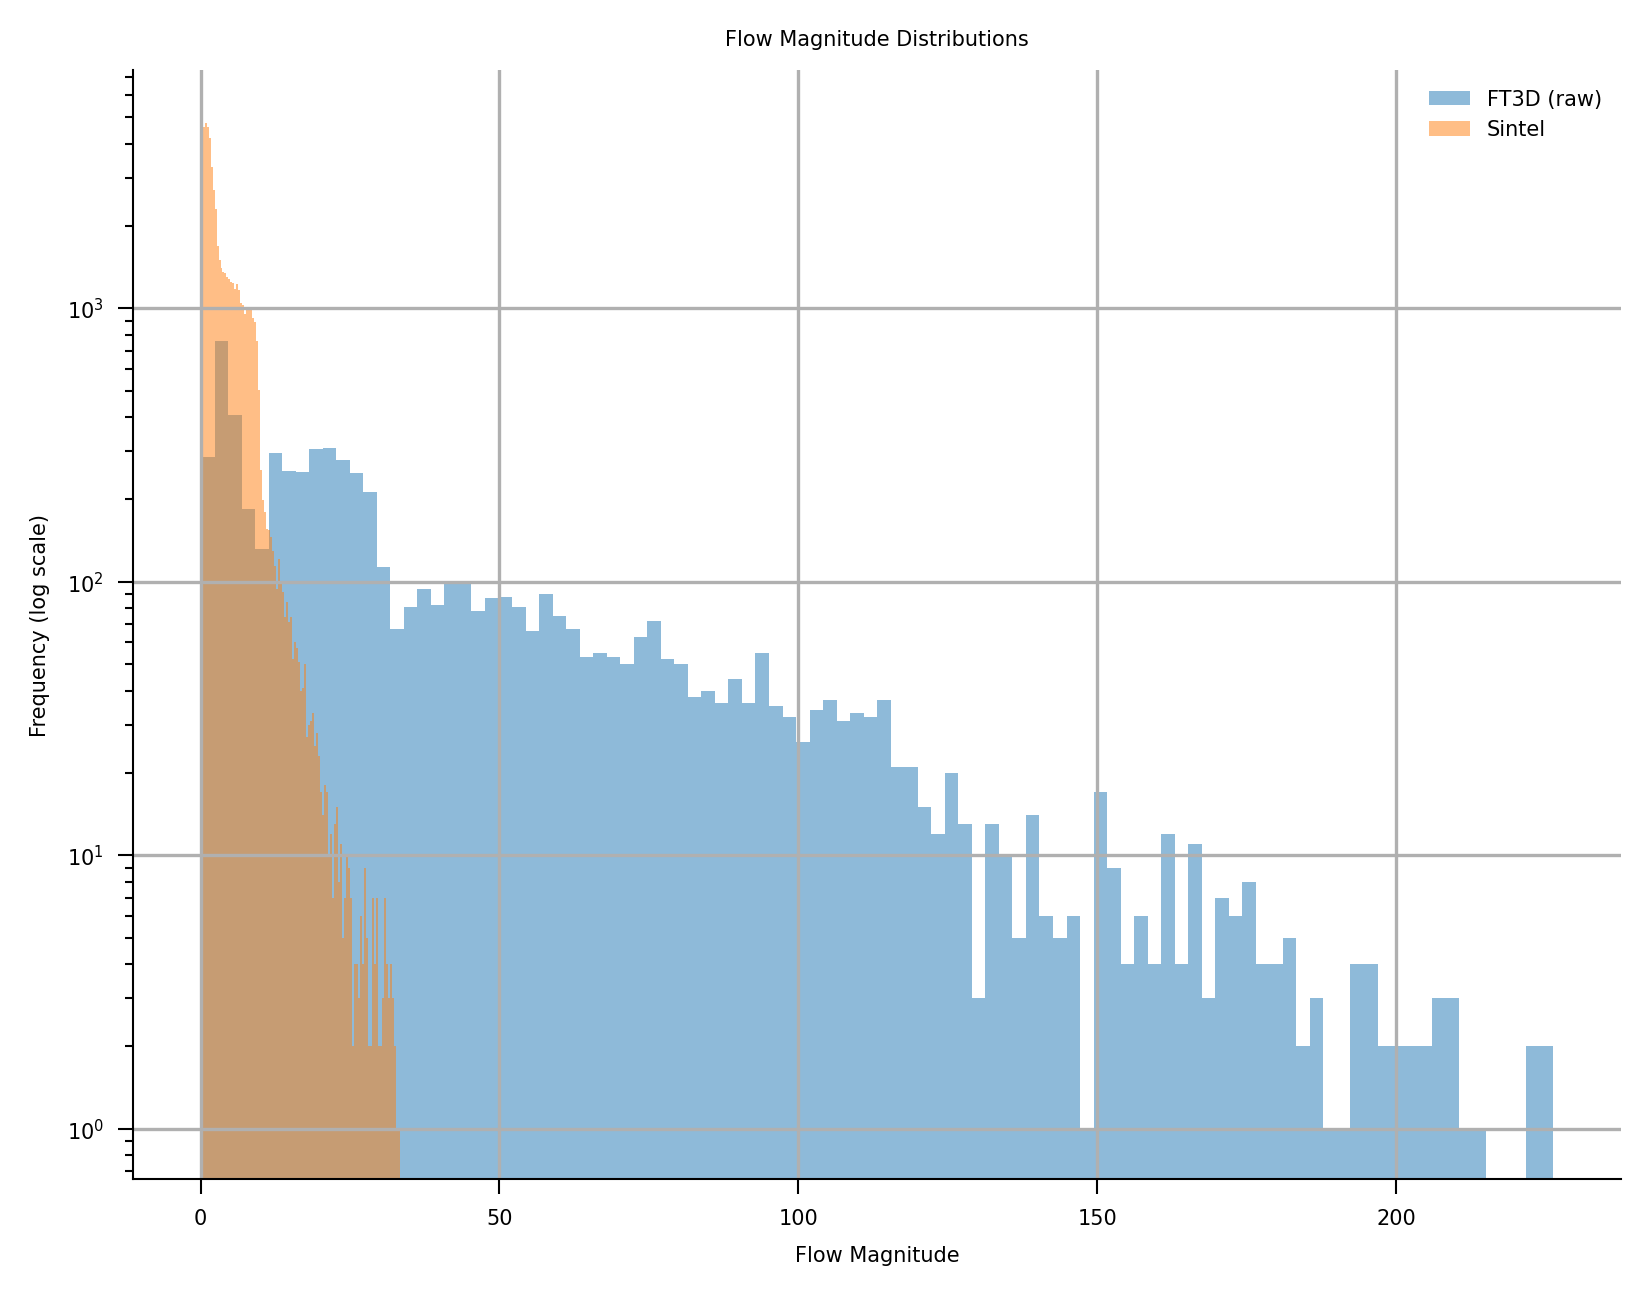

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Extract flow fields from dataset and convert to NumPy
ft3d_flow = dataset1[15]["flow"].cpu().numpy() 
sintel_flow = dataset[15]["flow"].cpu().numpy()

# Compute magnitudes
mags_ft3d = np.linalg.norm(ft3d_flow.reshape(-1, 2), axis=-1)
mags_sintel = np.linalg.norm(sintel_flow.reshape(-1, 2), axis=-1)

# Build quantile-based mapping
percentiles = np.linspace(0, 100, 1000)
ft3d_quantiles = np.percentile(mags_ft3d, percentiles)
sintel_quantiles = np.percentile(mags_sintel, percentiles)
mag_map = interp1d(ft3d_quantiles, sintel_quantiles, bounds_error=False, fill_value="extrapolate")

# Remap magnitudes while preserving direction
ft3d_flow_flat = ft3d_flow.reshape(-1, 2)
mags = np.linalg.norm(ft3d_flow_flat, axis=1, keepdims=True)
dirs = ft3d_flow_flat / (mags + 1e-8)
new_mags = mag_map(mags.squeeze()).reshape(-1, 1)
ft3d_flow_matched = dirs * new_mags

# Plot histograms
plt.hist(mags_ft3d, bins=100, alpha=0.5, label="FT3D (raw)")
#plt.hist(np.linalg.norm(ft3d_flow_matched, axis=1), bins=100, alpha=0.5, label="FT3D (matched)")
plt.hist(mags_sintel, bins=100, alpha=0.5, label="Sintel")
plt.yscale("log")
plt.legend()
plt.title("Flow Magnitude Distributions")
plt.xlabel("Flow Magnitude")
plt.ylabel("Frequency (log scale)")
plt.grid(True)
plt.show()



In [46]:
class MatchFlowCDF:
    """
    Remap FT3D flow magnitudes so their empirical CDF matches Sintel.
    Works entirely on the device of 'flow' (no CPU copies each step).
    """
    def __init__(self, q_src: torch.Tensor, q_tgt: torch.Tensor):
        self.q_src = q_src         # (Q,)
        self.q_tgt = q_tgt         # (Q,)

    @torch.no_grad()
    def __call__(self, sample: dict):
        flow = sample["flow"]                       # (H,W,2) or (2,H,W) – adapt as needed
        orig_shape = flow.shape

        f = flow.view(-1, 2)                        # (N,2)
        mag = torch.linalg.norm(f, dim=1)           # (N,)
        dir = f / (mag.unsqueeze(1) + 1e-8)

        # piece-wise linear interpolate using torch.searchsorted
        idx = torch.searchsorted(self.q_src.to(mag.device), mag.clamp(max=self.q_src[-1]))
        idx = idx.clamp(min=1, max=len(self.q_src) - 1)

        x0  = self.q_src[idx-1]
        x1  = self.q_src[idx]
        y0  = self.q_tgt[idx-1]
        y1  = self.q_tgt[idx]

        t   = (mag - x0) / (x1 - x0 + 1e-8)
        new_mag = y0 + t * (y1 - y0)                # (N,)

        flow_matched = (dir * new_mag.unsqueeze(1)).view(orig_shape)
        sample["flow"] = flow_matched
        return sample

class FT3DMatched(torch.utils.data.Dataset):
    def __init__(self, base_ds, flow_cdf_matcher):
        self.ds   = base_ds
        self.xfrm = flow_cdf_matcher
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        sample = self.ds[idx]
        return self.xfrm(sample)

ft3d_matched = torch.utils.data.Dataset()   # tiny wrapper

percentiles      = np.linspace(0, 100, 1000)
q_src            = np.percentile(mags_ft3d,   percentiles)   # 1 × 1000
q_tgt            = np.percentile(mags_sintel, percentiles)   # 1 × 1000
q_src = torch.as_tensor(q_src,  dtype=torch.float32)   # shape (Q,)
q_tgt = torch.as_tensor(q_tgt,  dtype=torch.float32)

flow_matcher   = MatchFlowCDF(q_src, q_tgt)
dataset1_matched = FT3DMatched(dataset1, flow_matcher)


# Training network and decoder on a single batch

We now train the network on a single batch to validate that the pipeline works. We do not expect these networks to generalize their function.

In [56]:
from tqdm.notebook import tqdm
from torch.optim import Adam
from torch.utils.data import DataLoader
import torch
from flyvis.network import Network
from flyvis.task.decoder import DecoderGAVP
from flyvis.analysis.animations.sintel import SintelSample
import matplotlib.pyplot as plt
from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.task.objectives import l2norm, epe
from flyvis.connectome import *
import os
from flyvis.datasets.FT3D import MultiTaskFlyingThings3D
from pathlib import Path

In [57]:
from copy import deepcopy
from flyvis.network import Network

# 1⃣  Grab defaults and make an editable copy
base_cfg = deepcopy(Network().config)

base_cfg.edge_config.syn_strength.groupby =[
                "source_type", "target_type",
                "source_index", "target_index",
            ]
net_custom = Network(
    node_config=base_cfg.node_config,
    edge_config=base_cfg.edge_config,    # keep the rest unchanged
    connectome=base_cfg.connectome,
    dynamics=base_cfg.dynamics,
    stimulus_config=base_cfg.stimulus_config,
)

print("free params:", net_custom.num_parameters.free)


[2025-05-31 02:49:12] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.
[2025-05-31 02:49:15] network:222 Initialized network with NumberOfParams(free=1513361, fixed=2959) parameters.


free params: 1513361


In [58]:
torch.cuda.empty_cache()


In [59]:
net_default = Network()


[2025-05-31 02:49:18] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


In [60]:
sintel = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

FT3D_ROOT      = Path(os.getenv("FT3D_ROOT", "/mnt/s/datasets/FlyingThings3D"))
augment = True
ft3d = MultiTaskFlyingThings3D(
        ft3d_path=FT3D_ROOT,
        tasks=["rgb", "flow"],
        augment=augment,
        _init_cache=True,
    )

[2025-05-31 02:49:18] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [ ]:
t_pre = 0.5
dt = 1 / 50
batch_size = 1
train_loader = DataLoader(sintel, batch_size=batch_size)
batch = next(iter(train_loader))


In [ ]:
torch.cuda.empty_cache()         # clears *cached* but not live memory
torch.cuda.ipc_collect()         # optional: clears inter-process handles


In [64]:
loss_fn = epe

[2025-05-31 03:08:23] decoder:282 Initialized decoder with NumberOfParams(free=7427, fixed=0) parameters.
[2025-05-31 03:08:23] decoder:283 DecoderGAVP(
  (base): Sequential(
    (0): Conv2dHexSpace(34, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Softplus(beta=1.0, threshold=20.0)
    (3): Dropout(p=0.5, inplace=False)
  )
  (decoder): Sequential(
    (0): Conv2dHexSpace(8, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (head): Sequential()
)
[2025-05-31 03:08:25] decoder:282 Initialized decoder with NumberOfParams(free=7427, fixed=0) parameters.
[2025-05-31 03:08:25] decoder:283 DecoderGAVP(
  (base): Sequential(
    (0): Conv2dHexSpace(34, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Softplus(beta=1.0, threshold=20.0)
    (3): Dropout(p=0.5, inplace=False)
  )
 

  0%|          | 0/5000 [00:00<?, ?it/s]

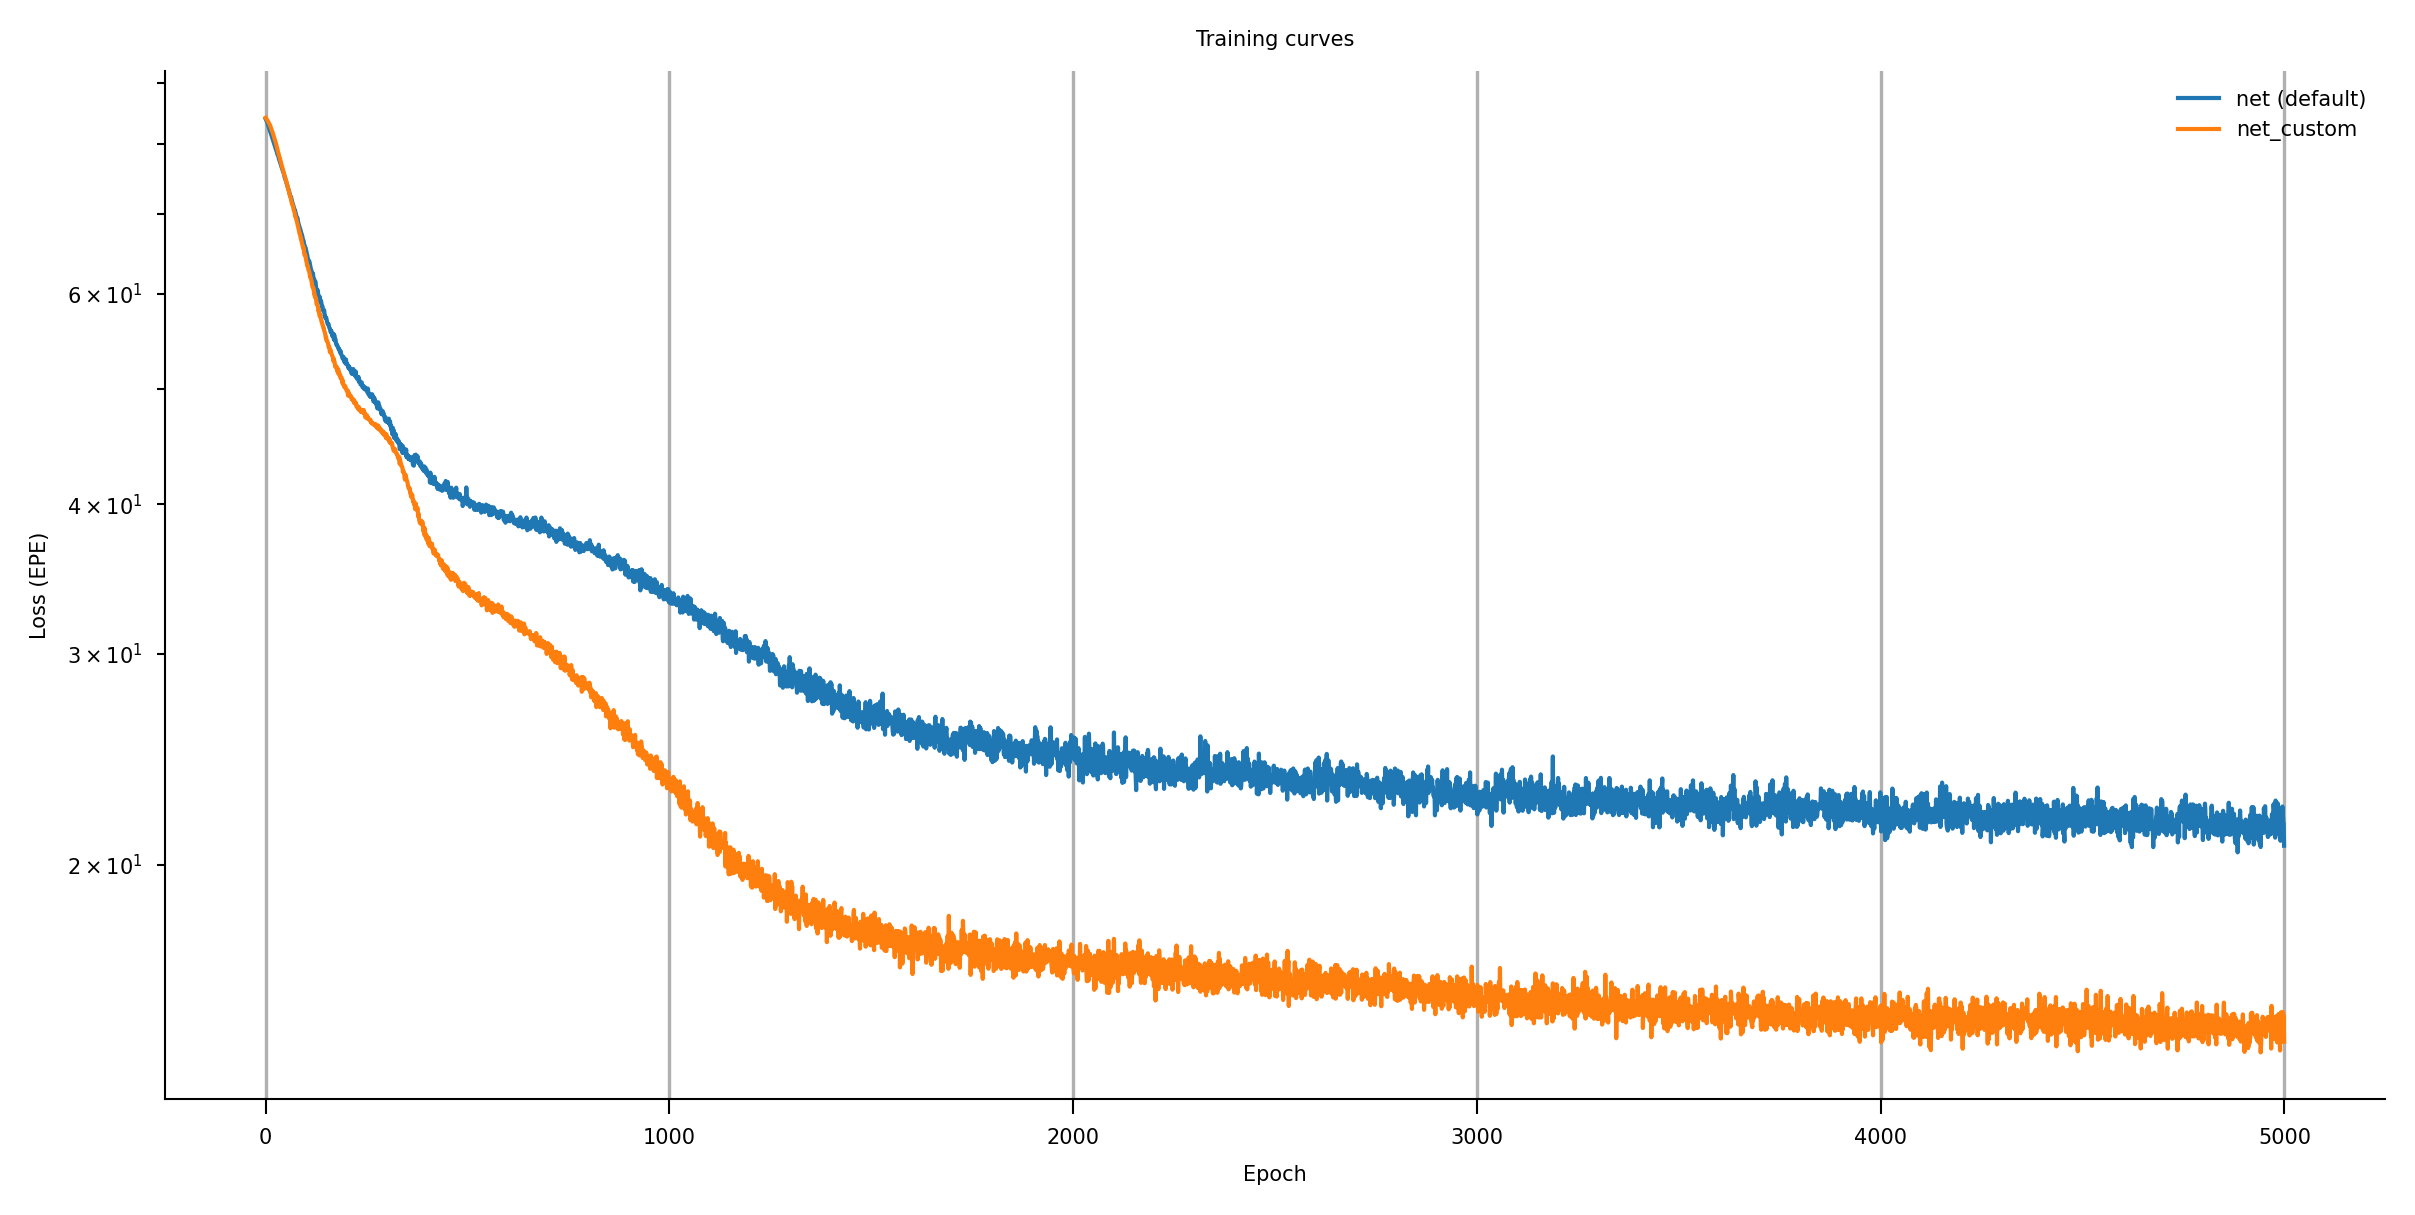

In [ ]:
epochs = 5000

errors_custom = []
errors_default = []    


initial_state_custom = net_custom.steady_state(t_pre, dt, batch_size)
initial_state_default = net_default.steady_state(t_pre, dt, batch_size)

decoder_custom = DecoderGAVP(net_custom.connectome, shape=[8, 2], kernel_size=5)
decoder_default = DecoderGAVP(net_default.connectome, shape=[8, 2], kernel_size=5)

optimizer_custom = Adam((*net_custom.parameters(), *decoder_custom.parameters()), lr=1e-4)
optimizer_default = Adam((*net_default.parameters(), *decoder_default.parameters()), lr=1e-4)


for e in tqdm(range(epochs)):
    lum = batch["rgb"]
    flow = batch["flow"]

    optimizer_custom.zero_grad()
    net_custom.stimulus.zero()
    net_custom.stimulus.add_input(lum)

    optimizer_default.zero_grad()
    net_default.stimulus.zero()
    net_default.stimulus.add_input(lum)


    activity_custom = net_custom(net_custom.stimulus(), dt=1 / 50, state=initial_state_custom)
    activity_default = net_default(net_default.stimulus(), dt=1 / 50, state=initial_state_default)

    y_pred_custom = decoder_custom(activity_custom)
    y_pred_default = decoder_default(activity_default)

    batch_error_custom = loss_fn(y_pred_custom, flow)
    batch_error_default = loss_fn(y_pred_default, flow)


    errors_custom.append(batch_error_custom.cpu().item())
    errors_default.append(batch_error_default.cpu().item())

    batch_error_custom.backward()
    batch_error_default.backward()

    optimizer_custom.step()
    optimizer_default.step()

    #if e % 10 == 0:
    #    print(f"Epoch {e}: {batch_error_custom.item()},{batch_error_default.item()}")

# ------------------------------------------------------------------
# Plot the two learning curves
plt.figure(figsize=(8,4))
plt.plot(errors_default, label="net (default)")
plt.plot(errors_custom,  label="net_custom")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (EPE)")
plt.title("Training curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [74]:
lum = batch["rgb"]   # Remove batch dimension
flow = batch["flow"][0] # Remove batch dimension


#stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
net_custom.stimulus.zero()
net_custom.stimulus.add_input(lum)
activity_custom = net_custom(net_custom.stimulus(), dt=1/50, state=initial_state_custom)

net_default.stimulus.zero()
net_default.stimulus.add_input(lum)
activity_custom = net_default(net_default.stimulus(), dt=1/50, state=initial_state_default)


In [75]:
y_pred_custom = decoder_custom(activity_custom)
y_pred_default = decoder_default(activity_default)

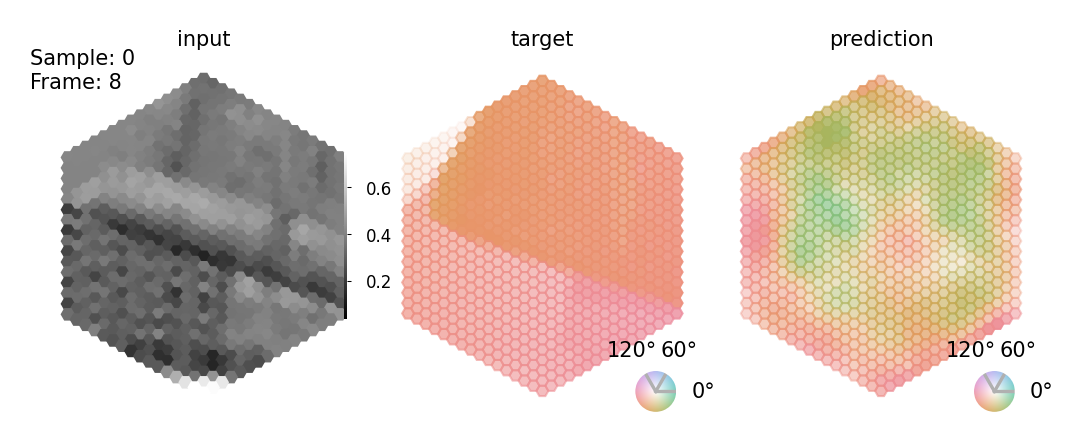

In [76]:
lum = batch["rgb"][0]   # Remove batch dimension
flow = batch["flow"][0] # Remove batch dimension
animation = SintelSample(lum[None], flow[None], prediction=y_pred_custom.detach().cpu())
animation.animate_in_notebook()

#animation = SintelSample(lum[None], flow[None], prediction=y_pred_default.detach().cpu())
#animation.animate_in_notebook()

In [ ]:
((y_pred - flow) ** 2).sqrt().mean()

tensor(0.6523, device='cuda:0', grad_fn=<MeanBackward0>)

# Evaluating trained networks

In [ ]:
from flyvis import results_dir
from flyvis.network import NetworkView
from flyvis.utils.activity_utils import LayerActivity

from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.task.decoder import DecoderGAVP

In [ ]:
# we load the best task-performing model from the presorted ensemble
network_view = NetworkView(results_dir / "flow/0000/000")

ValueError: NetworkDir not found at /home/z/flyvis/data/results/flow/0000/000.

In [ ]:
network = network_view.init_network()

In [ ]:
network_view.dir.config.task.decoder

In [ ]:
decoder = network_view.init_decoder()["flow"]

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    all_frames=False,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

In [ ]:
data = [dataset[i] for i in range(4)]
lum = torch.stack([d["lum"] for d in data])
flow = torch.stack([d["flow"] for d in data])

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[:, 0])
responses = network.simulate(lum, dataset.dt, initial_state=stationary_state)

In [ ]:
y_pred = decoder(responses)

We expect this network to generalize across sequences. This network sees motion into all directions.

In [ ]:
animation = SintelSample(lum, flow, prediction=y_pred.detach().cpu())
animation.animate_in_notebook()

We expect the accuracy is not as good as the overfitted example because this network generalized across the whole-dataset.

In [ ]:
((y_pred - flow) ** 2).sqrt().mean()

# Evaluating ensembles

Last, we evaluated the task error of the 50 trained networks on a held out set of sequences. We evaluated the task error across all checkpoints during training and show the minimal one in the histrogram below. This checkpoint we analyse with respect to it's tuning predictions as shown in the next notebooks.

In [ ]:
from flyvis import EnsembleView

In [ ]:
ensemble = EnsembleView("flow/0000")

NameError: name 'EnsembleView' is not defined

In [ ]:
ensemble.task_error_histogram()